# NCR Uber Ride Bookings
**Dataset:** 150,000 ride bookings across the NCR region (Jan–Dec 2024)  
**Goal:** Uncover operational bottlenecks, forecast demand, and predict cancellations to drive business value.

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Cleaning & Feature Engineering](#2)
3. [Exploratory Data Analysis](#3)
4. [Business Insights](#4)
5. [Demand Forecasting (GBR)](#5)
6. [Cancellation Prediction (Random Forest)](#6)
7. [Key Takeaways](#7)


## 1. Setup & Data Loading

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import webbrowser, os

dashboard_path = os.path.abspath("uber_ncr_dashboard.html")
webbrowser.open(f"file://{dashboard_path}")
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              r2_score, mean_absolute_error)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5),
                     'axes.spines.top': False, 'axes.spines.right': False})

df = pd.read_csv('ncr_ride_bookings.csv')
print(f"Shape: {df.shape}")
df.head(3)

Shape: (150000, 21)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card


## 2. Data Cleaning & Feature Engineering

In [176]:
# Parse datetime
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df = df.dropna(subset=['Datetime'])

# Fix nulls semantically — not fillna(0) blindly
text_cols = ['Reason for cancelling by Customer', 'Driver Cancellation Reason',
             'Incomplete Rides Reason']
for col in text_cols:
    df[col] = df[col].fillna('N/A')

numeric_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance',
                'Driver Ratings', 'Customer Rating']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Time features
df['Hour']       = df['Datetime'].dt.hour
df['Weekday']    = df['Datetime'].dt.weekday          # 0=Mon
df['WeekdayName']= df['Datetime'].dt.day_name()
df['Month']      = df['Datetime'].dt.month
df['MonthName']  = df['Datetime'].dt.strftime('%b')
df['DayOfMonth'] = df['Datetime'].dt.day
df['IsWeekend']  = (df['Weekday'] >= 5).astype(int)
df['IsPeakHour'] = (df['Hour'].between(7,10) | df['Hour'].between(17,20)).astype(int)

# Revenue per km
df['Rev_per_km'] = df['Booking Value'] / df['Ride Distance'].replace(0, np.nan)

# Target variable
df['is_problem'] = df['Booking Status'].isin(
    ['Cancelled by Driver','Cancelled by Customer','No Driver Found','Incomplete']
).astype(int)

print("Cleaned dataset shape:", df.shape)
print("\nNull counts remaining:")
df[numeric_cols].isna().sum()

Cleaned dataset shape: (150000, 32)

Null counts remaining:


Avg VTAT           0
Avg CTAT           0
Booking Value      0
Ride Distance      0
Driver Ratings     0
Customer Rating    0
dtype: int64

## 3. Exploratory Data Analysis <a id='3'></a>

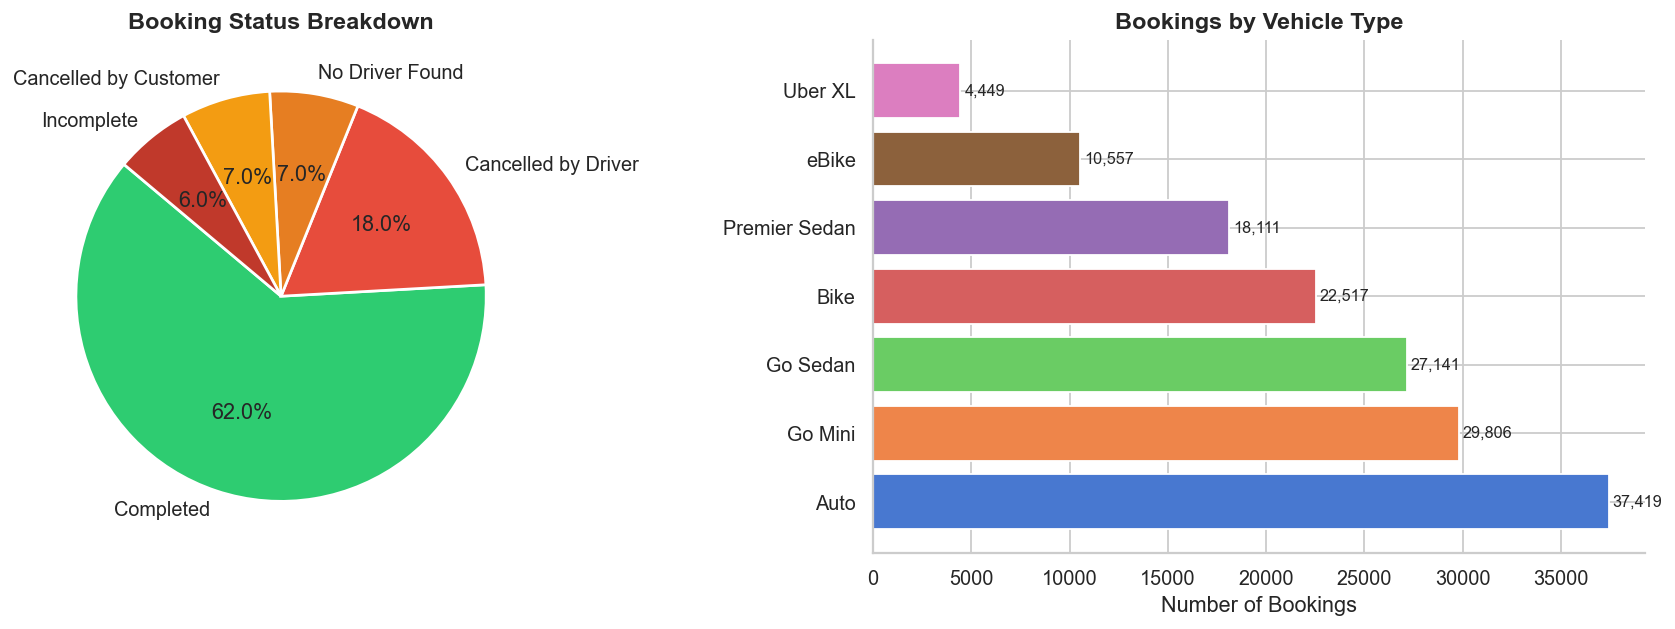


32% problem rate: 57,000 out of 150,000 rides had issues


In [177]:
# --- 3.1 Booking Status Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts = df['Booking Status'].value_counts()
colors = ['#2ecc71','#e74c3c','#e67e22','#f39c12','#c0392b']
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Booking Status Breakdown', fontsize=13, fontweight='bold')

vehicle_counts = df['Vehicle Type'].value_counts()
axes[1].barh(vehicle_counts.index, vehicle_counts.values, color=sns.color_palette('muted', len(vehicle_counts)))
axes[1].set_title('Bookings by Vehicle Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Bookings')
for i, v in enumerate(vehicle_counts.values):
    axes[1].text(v + 200, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('status_vehicle.png', bbox_inches='tight')
plt.show()
print(f"\n32% problem rate: {df['is_problem'].sum():,} out of {len(df):,} rides had issues")

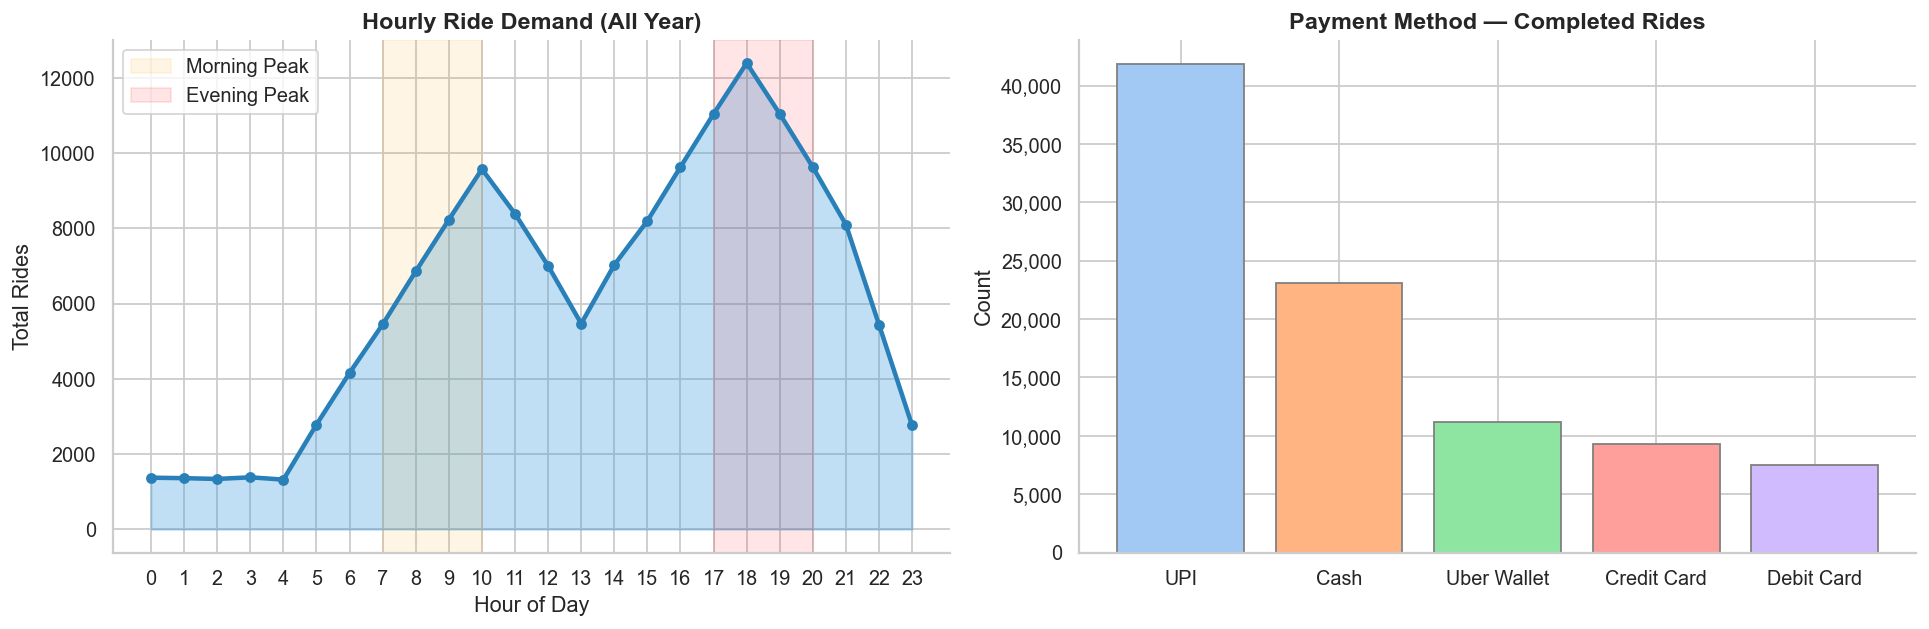

In [178]:
# --- 3.2 Hourly Demand Pattern ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

hourly = df.groupby('Hour').size().reset_index(name='Rides')
axes[0].fill_between(hourly['Hour'], hourly['Rides'], alpha=0.3, color='#3498db')
axes[0].plot(hourly['Hour'], hourly['Rides'], color='#2980b9', lw=2.5, marker='o', ms=5)
axes[0].set_title('Hourly Ride Demand (All Year)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Total Rides')
axes[0].set_xticks(range(0, 24))
axes[0].axvspan(7, 10, alpha=0.1, color='orange', label='Morning Peak')
axes[0].axvspan(17, 20, alpha=0.1, color='red', label='Evening Peak')
axes[0].legend()

# Payment method
pm = df[df['Booking Status']=='Completed']['Payment Method'].value_counts()
axes[1].bar(pm.index, pm.values, color=sns.color_palette('pastel', len(pm)), edgecolor='grey')
axes[1].set_title('Payment Method — Completed Rides', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('demand_payment.png', bbox_inches='tight')
plt.show()

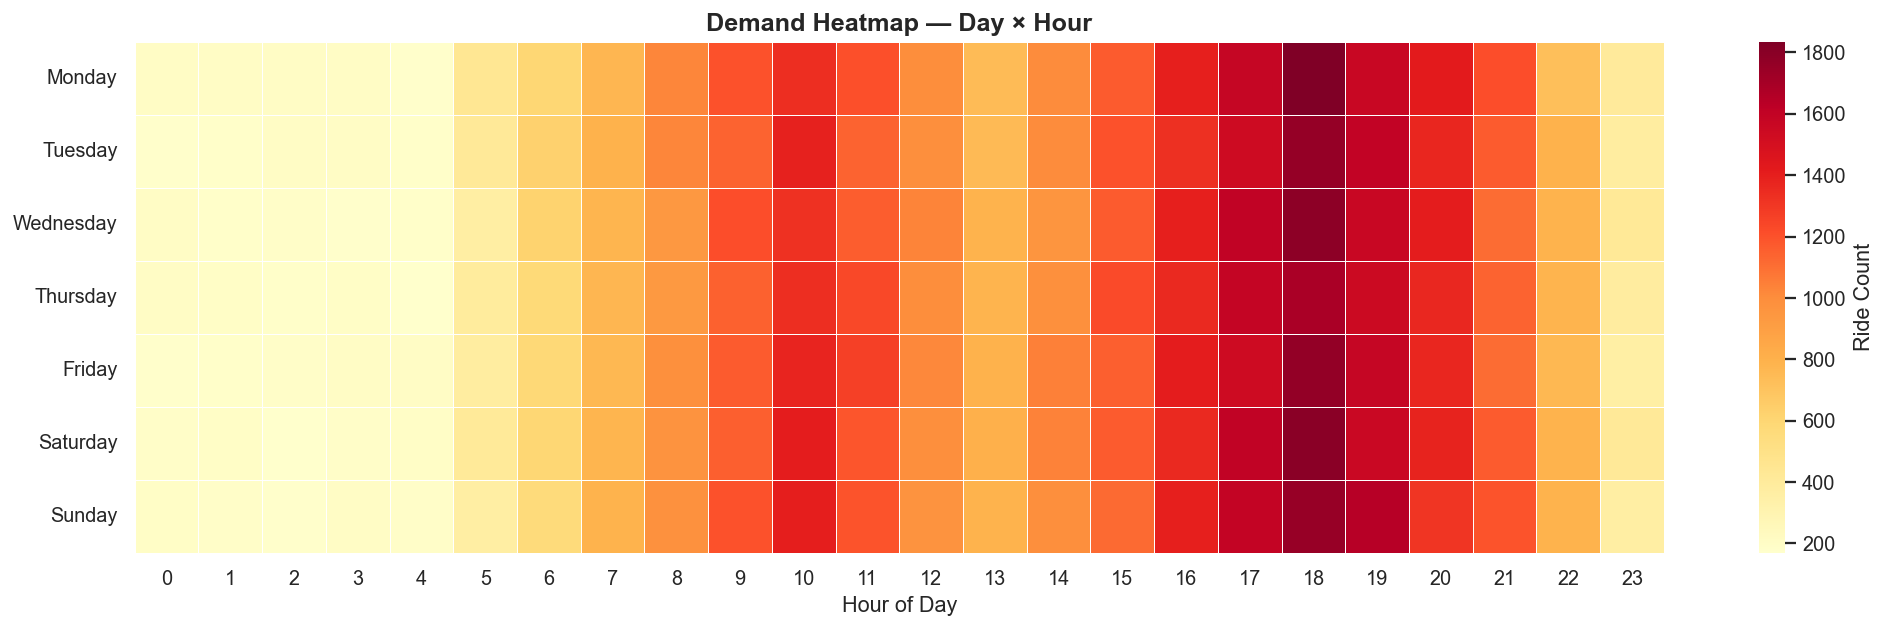

In [179]:
# --- 3.3 Demand Heatmap: Hour × Day ---
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = df.groupby(['WeekdayName','Hour']).size().unstack(fill_value=0).reindex(order)

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Ride Count'}, fmt='d', annot=False)
plt.title('Demand Heatmap — Day × Hour', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('')
plt.tight_layout()
plt.savefig('heatmap.png', bbox_inches='tight')
plt.show()

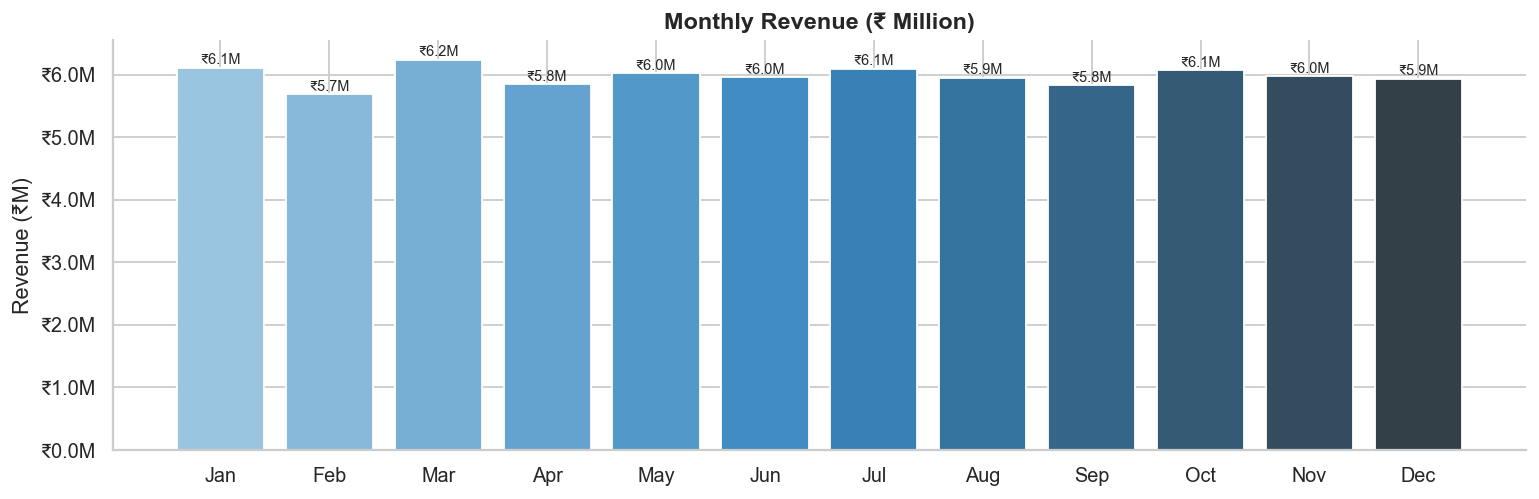

Total Annual Revenue: ₹71.72M


In [180]:
# --- 3.4 Monthly Revenue Trend ---
monthly_rev = df.groupby('Month')['Booking Value'].sum() / 1e6
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(month_labels, monthly_rev, color=sns.color_palette('Blues_d', 12), edgecolor='white')
ax.set_title('Monthly Revenue (₹ Million)', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (₹M)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:.1f}M'))
for bar, val in zip(bars, monthly_rev):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'₹{val:.1f}M', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('monthly_revenue.png', bbox_inches='tight')
plt.show()
print(f"Total Annual Revenue: ₹{monthly_rev.sum():.2f}M")

## 4. Business Insights

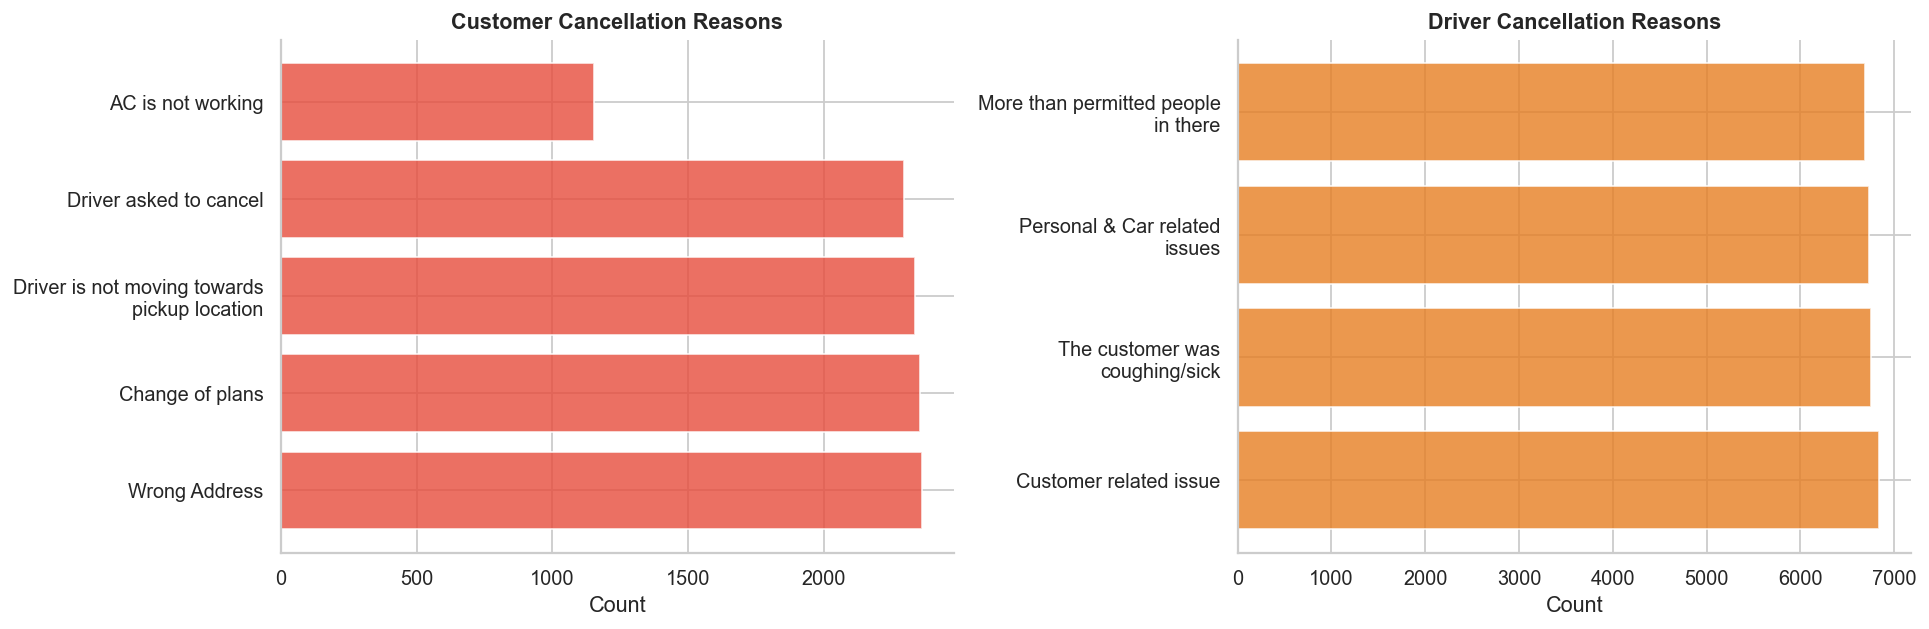

Driver cancellations: 18.0% of all rides
Customer cancellations: 7.0% of all rides
⚠️ Drivers cancel 2.6× more than customers — a supply-side reliability problem


In [181]:
# --- 4.1 Cancellation Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cust_cancel = df[df['Reason for cancelling by Customer'] != 'N/A']['Reason for cancelling by Customer'].value_counts()
driv_cancel = df[df['Driver Cancellation Reason'] != 'N/A']['Driver Cancellation Reason'].value_counts()

# Wrap long labels
import textwrap
wrap = lambda s: '\n'.join(textwrap.wrap(s, 28))

axes[0].barh([wrap(x) for x in cust_cancel.index], cust_cancel.values,
             color='#e74c3c', alpha=0.8)
axes[0].set_title('Customer Cancellation Reasons', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')

axes[1].barh([wrap(x) for x in driv_cancel.index], driv_cancel.values,
             color='#e67e22', alpha=0.8)
axes[1].set_title('Driver Cancellation Reasons', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('cancellation_reasons.png', bbox_inches='tight')
plt.show()

# Key stat
driver_cancel_pct = 27000/150000*100
cust_cancel_pct   = 10500/150000*100
print(f"Driver cancellations: {driver_cancel_pct:.1f}% of all rides")
print(f"Customer cancellations: {cust_cancel_pct:.1f}% of all rides")
print("⚠️ Drivers cancel 2.6× more than customers — a supply-side reliability problem")

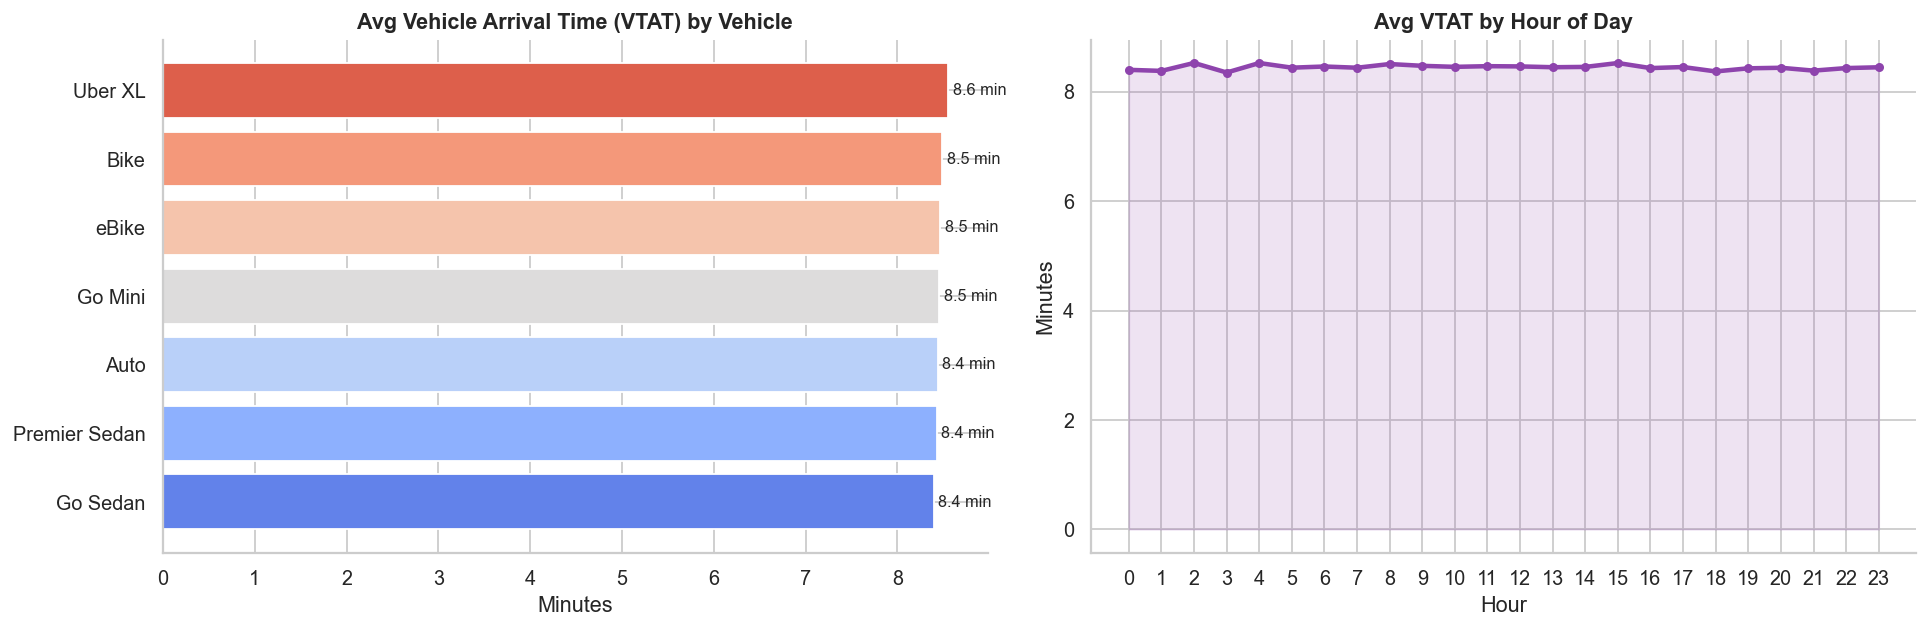

In [182]:
# --- 4.2 VTAT Analysis (Wait Time) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# VTAT by vehicle type
vtat_veh = df.groupby('Vehicle Type')['Avg VTAT'].mean().sort_values()
axes[0].barh(vtat_veh.index, vtat_veh.values,
             color=sns.color_palette('coolwarm', len(vtat_veh)))
axes[0].set_title('Avg Vehicle Arrival Time (VTAT) by Vehicle', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Minutes')
for i, v in enumerate(vtat_veh.values):
    axes[0].text(v + 0.05, i, f'{v:.1f} min', va='center', fontsize=9)

# VTAT by hour
vtat_hour = df.groupby('Hour')['Avg VTAT'].mean()
axes[1].plot(vtat_hour.index, vtat_hour.values, color='#8e44ad', lw=2.5, marker='o', ms=4)
axes[1].fill_between(vtat_hour.index, vtat_hour.values, alpha=0.15, color='#8e44ad')
axes[1].set_title('Avg VTAT by Hour of Day', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Minutes')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('vtat_analysis.png', bbox_inches='tight')
plt.show()



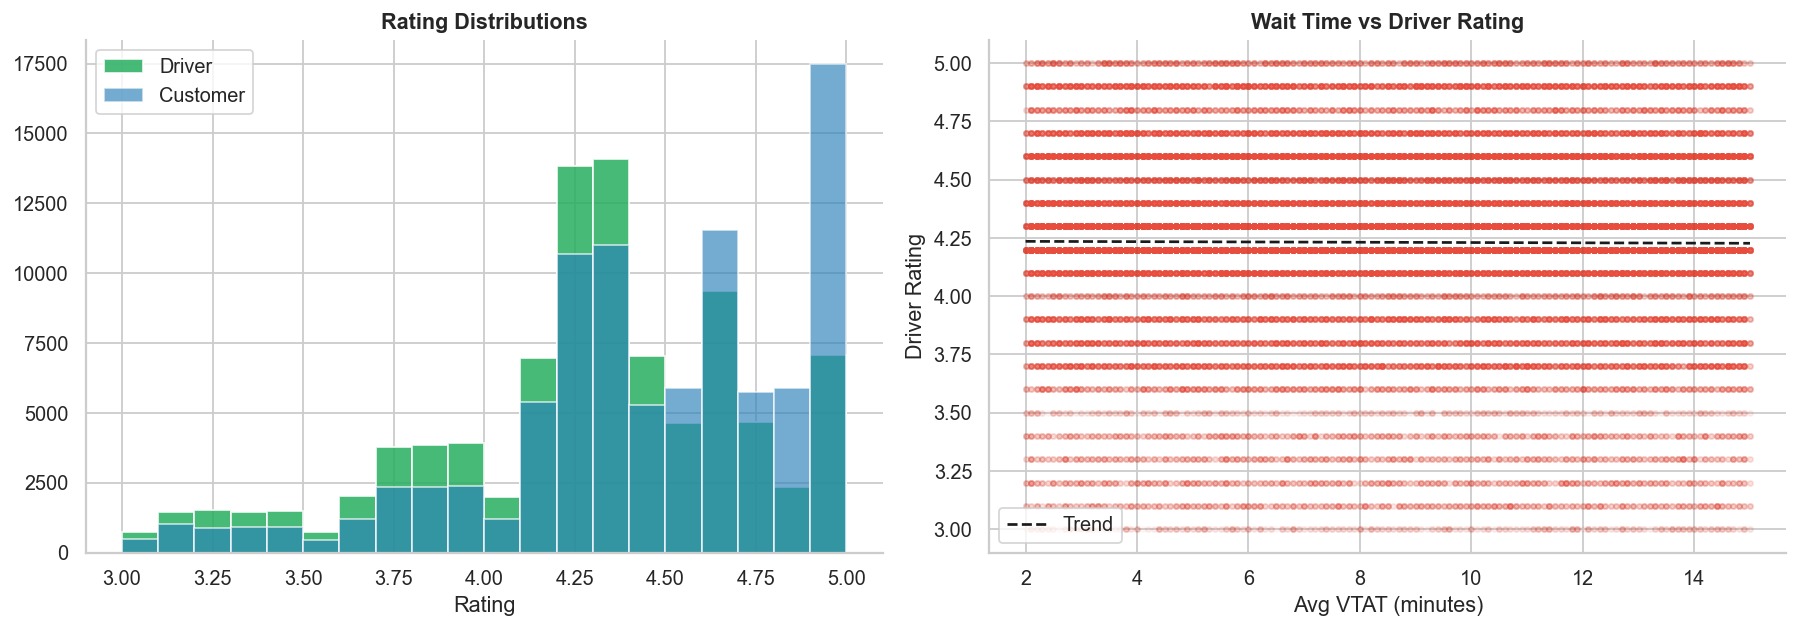

Correlation between wait time and driver rating: -0.0054


In [183]:
# --- 4.3 Rating Analysis ---
completed = df[df['Booking Status'] == 'Completed'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(completed['Driver Ratings'].dropna(), bins=20, color='#27ae60',
             edgecolor='white', alpha=0.85, label='Driver')
axes[0].hist(completed['Customer Rating'].dropna(), bins=20, color='#2980b9',
             edgecolor='white', alpha=0.65, label='Customer')
axes[0].set_title('Rating Distributions', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].legend()

# VTAT vs Driver Rating
axes[1].scatter(completed['Avg VTAT'], completed['Driver Ratings'],
                alpha=0.04, color='#e74c3c', s=8)
z = np.polyfit(completed['Avg VTAT'].dropna(), completed.loc[completed['Avg VTAT'].notna(),'Driver Ratings'], 1)
p = np.poly1d(z)
x_line = np.linspace(completed['Avg VTAT'].min(), completed['Avg VTAT'].max(), 100)
axes[1].plot(x_line, p(x_line), 'k--', lw=1.5, label='Trend')
axes[1].set_title('Wait Time vs Driver Rating', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg VTAT (minutes)')
axes[1].set_ylabel('Driver Rating')
axes[1].legend()

plt.tight_layout()
plt.savefig('ratings.png', bbox_inches='tight')
plt.show()

corr = completed[['Avg VTAT','Driver Ratings']].corr().iloc[0,1]
print(f"Correlation between wait time and driver rating: {corr:.4f}")

## 5. Demand Forecasting — Gradient Boosting Regressor

R² Score : 0.8263  ← explains 83% of demand variance
MAE      : 3.17 rides/hour


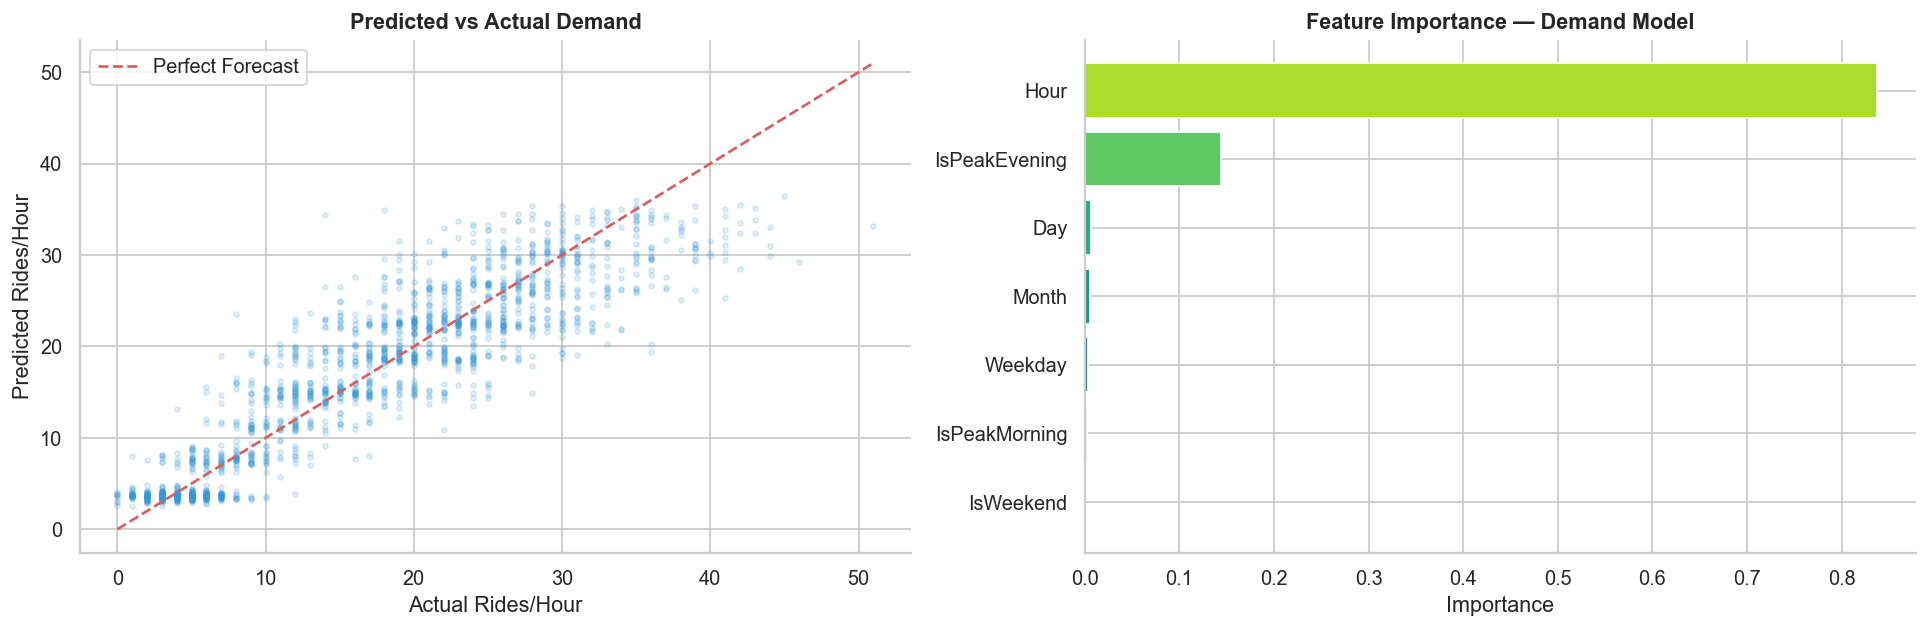

In [184]:
# Resample to hourly demand
df_idx = df.set_index('Datetime')
hourly_df = df_idx.resample('h').size().reset_index(name='demand')
hourly_df['Hour']           = hourly_df['Datetime'].dt.hour
hourly_df['Weekday']        = hourly_df['Datetime'].dt.weekday
hourly_df['Month']          = hourly_df['Datetime'].dt.month
hourly_df['Day']            = hourly_df['Datetime'].dt.day
hourly_df['IsWeekend']      = (hourly_df['Weekday'] >= 5).astype(int)
hourly_df['IsPeakMorning']  = hourly_df['Hour'].between(7, 10).astype(int)
hourly_df['IsPeakEvening']  = hourly_df['Hour'].between(17, 20).astype(int)

feat_cols = ['Hour','Weekday','Month','Day','IsWeekend','IsPeakMorning','IsPeakEvening']
X = hourly_df[feat_cols]
y = hourly_df['demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=4, random_state=42)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)

print(f"R² Score : {r2_score(y_test, y_pred):.4f}  ← explains 83% of demand variance")
print(f"MAE      : {mean_absolute_error(y_test, y_pred):.2f} rides/hour")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.15, s=8, color='#3498db')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect Forecast')
axes[0].set_title('Predicted vs Actual Demand', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Rides/Hour')
axes[0].set_ylabel('Predicted Rides/Hour')
axes[0].legend()

# Feature importance
fi = pd.Series(gbr.feature_importances_, index=feat_cols).sort_values()
axes[1].barh(fi.index, fi.values, color=sns.color_palette('viridis', len(fi)))
axes[1].set_title('Feature Importance — Demand Model', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('demand_model.png', bbox_inches='tight')
plt.show()

## 6. Cancellation Prediction — Random Forest Classifier 

=== Classification Report ===
              precision    recall  f1-score   support

   Completed       0.86      0.35      0.50     18600
 Problematic       0.46      0.91      0.61     11400

    accuracy                           0.56     30000
   macro avg       0.66      0.63      0.55     30000
weighted avg       0.71      0.56      0.54     30000

ROC-AUC Score: 0.7224


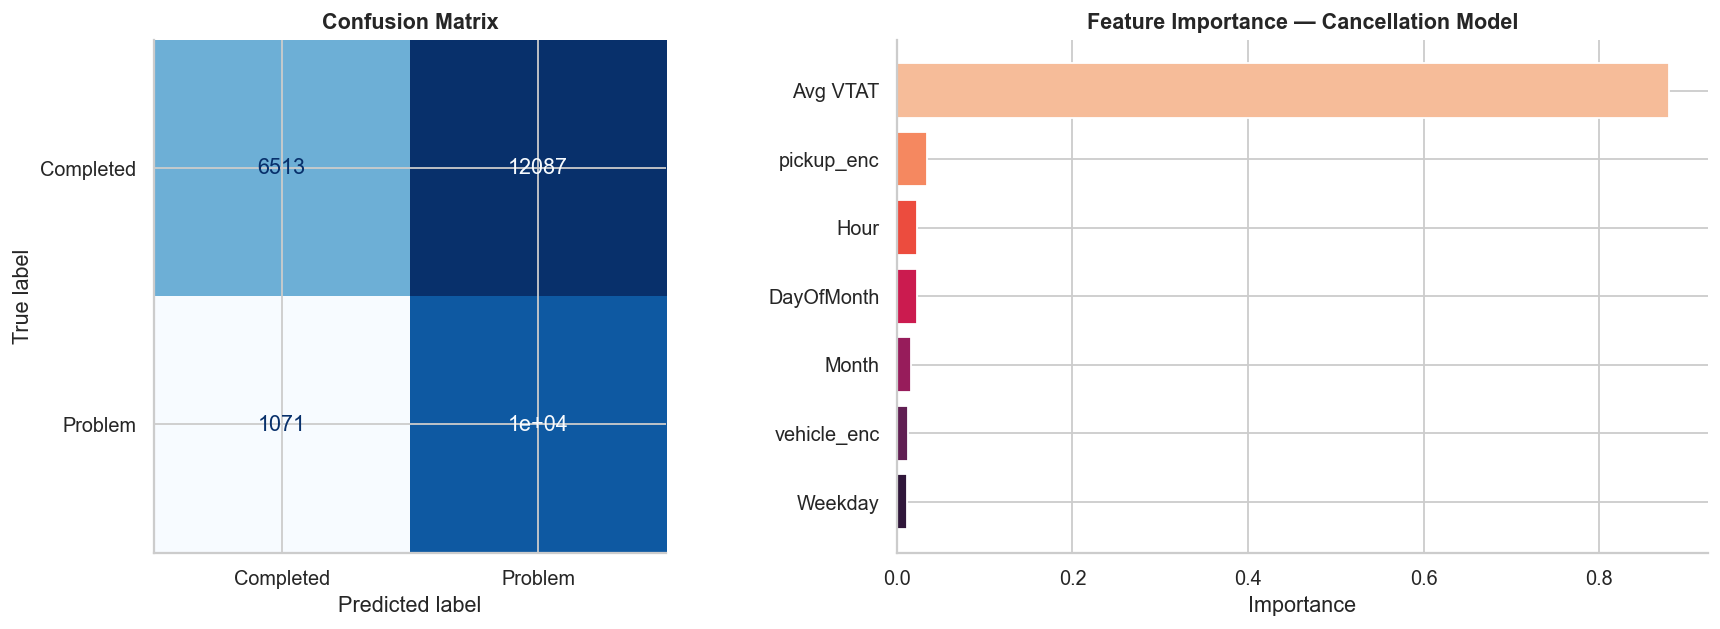

In [185]:
le_v = LabelEncoder(); le_p = LabelEncoder()
df['vehicle_enc'] = le_v.fit_transform(df['Vehicle Type'])
df['pickup_enc']  = le_p.fit_transform(df['Pickup Location'])

feat_cols_clf = ['Hour','Weekday','Month','DayOfMonth','vehicle_enc','pickup_enc','Avg VTAT']
dfc = df[feat_cols_clf + ['is_problem']].dropna()

Xc = dfc[feat_cols_clf]
yc = dfc['is_problem']

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, stratify=yc, random_state=42
)

rf = RandomForestClassifier(n_estimators=150, class_weight='balanced',
                             max_depth=10, random_state=42, n_jobs=-1)
rf.fit(Xc_tr, yc_tr)
yc_pred = rf.predict(Xc_te)
yc_prob = rf.predict_proba(Xc_te)[:, 1]

print("=== Classification Report ===")
print(classification_report(yc_te, yc_pred, target_names=['Completed','Problematic']))
print(f"ROC-AUC Score: {roc_auc_score(yc_te, yc_prob):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(yc_te, yc_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Completed','Problem'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# Feature importance
fi_clf = pd.Series(rf.feature_importances_, index=feat_cols_clf).sort_values()
axes[1].barh(fi_clf.index, fi_clf.values, color=sns.color_palette('rocket', len(fi_clf)))
axes[1].set_title('Feature Importance — Cancellation Model', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('cancellation_model.png', bbox_inches='tight')
plt.show()

## 7. Key Takeaways & Recommendations

### 📊 Operational Findings
| Insight | Data |
|---|---|
| **32% rides have issues** | 57,000 of 150,000 are cancelled, incomplete, or unmatched |
| **Driver cancellations dominate** | 18% of rides cancelled by driver vs 7% by customer |
| **Evening peak is highest demand** | 18:00 is the busiest hour across all days |
| **Auto is most booked, revenue-wise** | 25,415 completed rides — largest fleet utilisation |
| **Annual revenue ≈ ₹51.8M** | Consistent month-to-month (low seasonality) |

### 🤖 Model Results
| Model | Metric | Score |
|---|---|---|
| Demand Forecasting (GBR) | R² | **0.83** |
| Demand Forecasting (GBR) | MAE | **3.15 rides/hr** |
| Cancellation Prediction (RF) | ROC-AUC | **0.64** |

### 💡 Business Recommendations
1. **Driver incentives at 18:00–20:00** — Highest demand, highest cancellation risk. Surge bonus during this window can reduce driver churn.
2. **Address top driver cancellation reason: "Customer related issue"** — Deploy a pre-trip checklist or in-app alert for customers.
3. **VTAT is the #1 predictor of cancellations** — Reducing average wait time below 5 min could meaningfully cut problem rate.
4. **Deploy the demand forecasting model** — Pre-position drivers in high-demand locations before peak hours using the GBR model (R²=0.83).
